In [20]:
from nrem_analysis.constant import PROCESSED_DIR, FIGURES_DIR
from pathlib import Path

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from cmap import Colormap

cm = Colormap("colorbrewer:Set2")

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

STATE_NAMES = ["continuous", "fragmented", "stationary"]
MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]
DATA_DIR = Path("/Users/iii9781/nrem_analysis/data/movement_var20")

### Visualize STA

In [25]:
def plot_sta(sta_awake, sta_nrem, turn_units):
    ncols = 5
    nrows = int(np.ceil(sta_awake.shape[1] / ncols))

    f, axs = plt.subplots(
        nrows, ncols,
        figsize=(16, 8),
        sharex=True,
        # sharey=True,
        constrained_layout=True,
        )

    order = np.argsort(turn_units['turn_index'].values)
    axs = axs.flatten()
    for i, idx in enumerate(order):
        uid = turn_units.index[idx].item()
        ax = axs[i]

        for sta, color in zip([sta_awake, sta_nrem], ['b', 'r']):
            zero_idx = np.where(sta.index == 0)[0].item()
            baseline = sta[zero_idx, :]
            sta_norm = sta - baseline
            ax.plot(sta_norm[:, idx], color=color)
        
        ax.set_title(f"TSI: {turn_units['turn_index'].values[idx]:.2f} (Unit: {uid})")
        
        ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
        ax.axvline(0.2, color='r', linestyle='--', linewidth=0.4)
        ax.axvline(-0.2, color='r', linestyle='--', linewidth=0.4)

    f.legend(['Awake', 'NREM'], loc='lower right')
    return f, ax

In [ ]:
save_dir = FIGURES_DIR
save_dir.mkdir(exist_ok=True)

tsi              = []
sta_awakes       = []
sta_nrems        = []
sta_nrem_conts   = []
for mouse_id in MOUSE_IDS:
    mouse_dir = DATA_DIR / mouse_id

    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    sta_awake       = nap.load_file(mouse_dir / "sta_awake.npz")
    sta_nrem_cont   = nap.load_file(mouse_dir / "sta_nrem_cont.npz")
    sta_nrem        = nap.load_file(mouse_dir / "sta_nrem.npz")

    tsi.append(turn_units['turn_index'].values)
    sta_awakes.append(sta_awake)
    sta_nrems.append(sta_nrem)
    sta_nrem_conts.append(sta_nrem_cont)

    f, ax = plot_sta(sta_awake, sta_nrem, turn_units)
    f.suptitle(f"{mouse_id} (all NREM epochs)", fontsize=20)
    plt.savefig(save_dir / f"sta_{mouse_id}.png")
    plt.close(f)

    f, ax = plot_sta(sta_awake, sta_nrem_cont, turn_units)
    f.suptitle(f"{mouse_id} (Continuous NREM epochs)", fontsize=20)
    plt.savefig(save_dir / f"sta_{mouse_id}_cont.png")
    plt.close(f)

sta_awake       = np.column_stack(sta_awakes)
sta_nrem        = np.column_stack(sta_nrems)
sta_nrem_cont   = np.column_stack(sta_nrem_conts)
order           = np.argsort(np.concatenate(tsi))

In [51]:
turn_units

  Index     rate    turn_index  is_cw
-------  -------  ------------  -------
     79  0.35842         -0.2   False
     96  1.55923         -0.46  False
    114  2.2688          -0.1   False
    176  0.2328           0.15  True
    230  0.17558          0.19  True
    236  1.46843          0.17  True
    259  2.29407         -0.09  False

In [50]:
sta_awakes[0]

Time (s)          0        1        2        3        4  ...
----------  -------  -------  -------  -------  -------  -----
-0.5        94.6436  92.3903  85.3397  99.6463  96.0374  ...
-0.499      94.6403  92.3898  85.3393  99.647   96.0356  ...
-0.498      94.6389  92.3891  85.3395  99.6477  96.0343  ...
-0.497      94.6406  92.3918  85.3389  99.6489  96.0301  ...
-0.496      94.6419  92.3928  85.3383  99.6512  96.0285  ...
-0.495      94.6442  92.3942  85.338   99.6517  96.0272  ...
-0.494      94.6474  92.3958  85.3387  99.6529  96.0271  ...
...                                                      ...
0.494       96.5419  93.6984  85.7452  98.9353  96.6166  ...
0.495       96.5421  93.697   85.7471  98.934   96.616   ...
0.496       96.5431  93.6974  85.7495  98.9329  96.6205  ...
0.497       96.5419  93.6979  85.7489  98.931   96.6196  ...
0.498       96.542   93.6974  85.7509  98.9308  96.6208  ...
0.499       96.5424  93.6971  85.7535  98.9291  96.6218  ...
0.5         96.546   9

In [47]:
np.concatenate(orders)

array([ 1.6474016 ,  0.5486485 ,  0.10043396,  0.17031432, -0.18481174,
       -0.66652281, -0.21091855, -0.76303588, -0.69816979,  0.29147707,
        0.68422082,  0.36419053,  0.08861064, -0.51432964,  0.1717789 ,
       -0.1249561 , -0.61858394,  0.30525938, -0.05357799,  0.10600456,
        0.21139165, -0.95350642, -0.60580936, -0.82835239,  0.05642943,
        0.29995913,  0.25246364,  0.18082467,  0.43338605,  0.31166851,
       -0.06266167,  0.45103394,  0.67537605,  1.20582739,  1.88844082,
        0.13603066,  1.32758668,  1.0827991 ,  1.0592736 ,  1.00068152,
        1.15417998,  0.55969319,  0.31204278, -0.01605945, -0.06235345,
        0.19416041,  1.12218605, -0.29299447, -0.05986871, -0.07408799,
        0.26106976,  1.14705564, -0.18531768, -0.03879942,  0.08888677,
        0.46800065,  1.29505298, -0.60808686,  0.39375198,  2.06799422,
        1.21491799,  0.92760467,  1.19921687,  1.55840363,  0.53021224,
        0.64176689,  1.10371073,  1.17886499, -0.17473273,  0.76

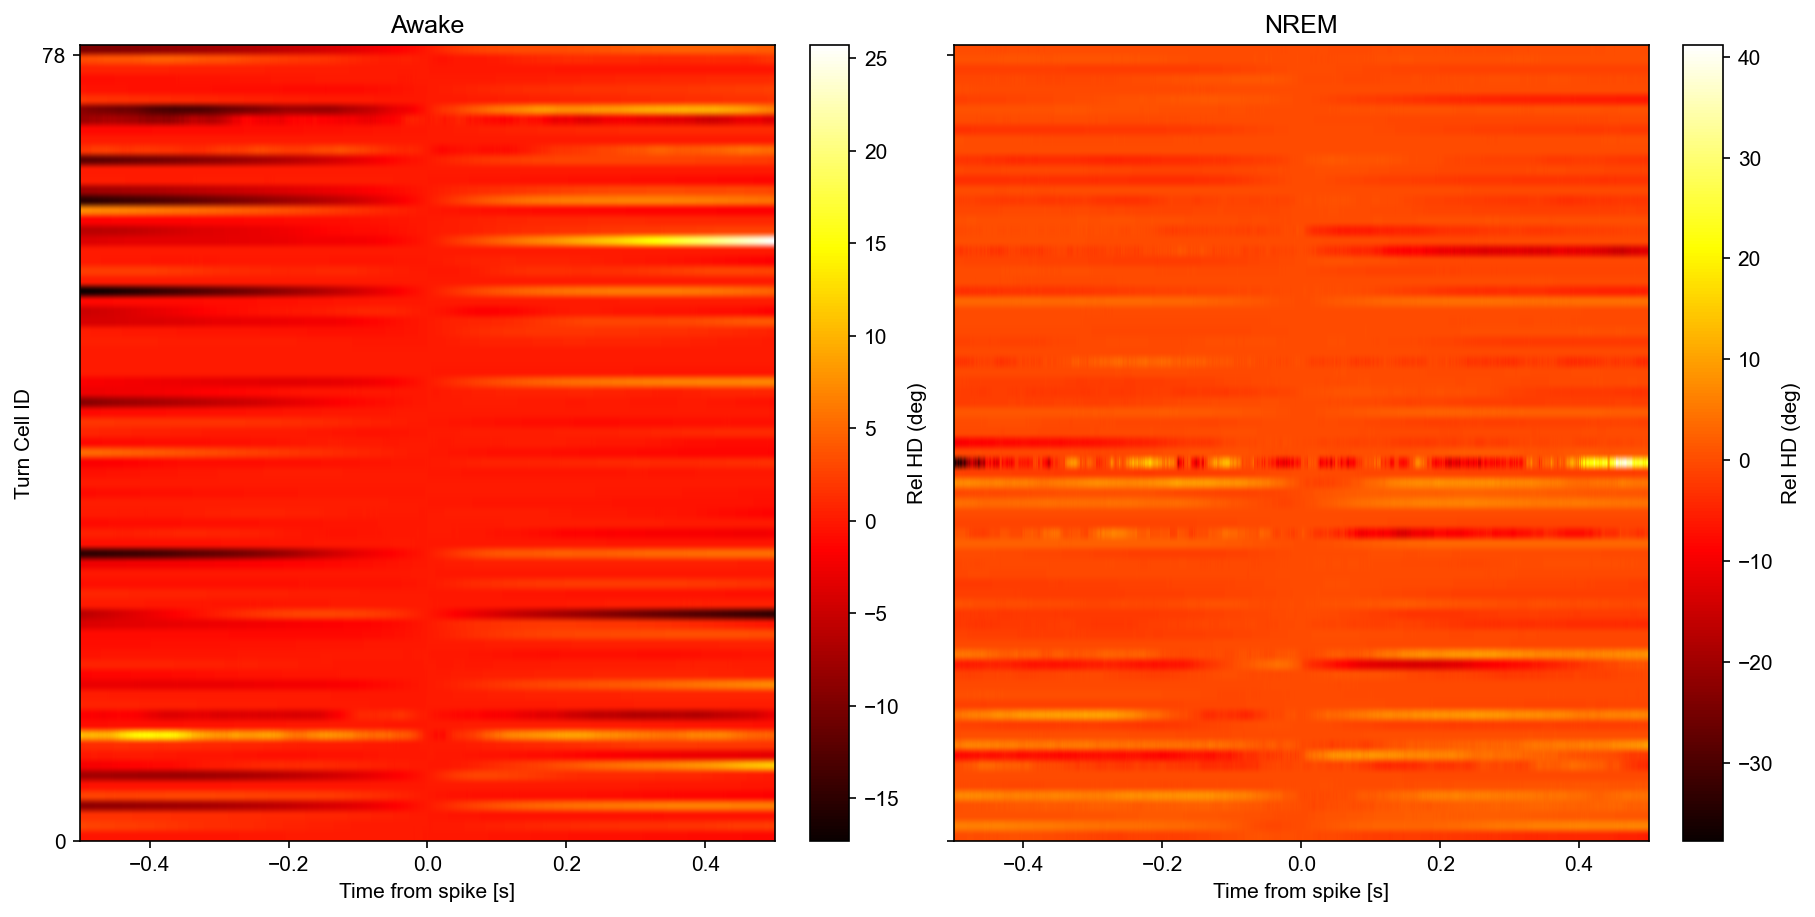

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem], ["Awake", "NREM"])):
    zero_idx = np.where(sta.index == 0)[0].item()
    baseline = sta[zero_idx, :]
    sta_norm = sta - baseline
    sta_norm = sta_norm[:, order]
    if sta is sta_nrem:
        sta_norm[:, 32] = 0

    im = axes[i].imshow(sta_norm.d.T, aspect='auto', origin='lower', extent=[sta_norm.index[0], sta_norm.index[-1], 0, sta_norm.shape[1]], cmap='hot')
    plt.colorbar(im, ax=axes[i], label='Rel HD (deg)')
    axes[i].set_title(f"{state}")
    axes[i].spines['top'].set_visible(True)
    axes[i].spines['right'].set_visible(True)
    axes[i].set_xlabel("Time from spike [s]")

    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_yticks([0, sta_norm.shape[1]-1])
# plt.savefig(FIGURES_DIR / "heatmap.png")

### Turn amplitude

In [19]:
sta_awake = []
sta_nrem = []

for mouse_id in MOUSE_IDS:
    mouse_dir = DATA_DIR / mouse_id
    
    sta_awake.append(nap.load_file(mouse_dir / "sta_awake.npz").d)
    sta_nrem.append(nap.load_file(mouse_dir / "sta_nrem.npz").d)

sta_awake = np.concatenate(sta_awake, axis=1)
sta_nrem = np.concatenate(sta_nrem, axis=1)
t = nap.load_file(mouse_dir / "sta_awake.npz").t


before_idx = np.where(t == -0.2)[0][0]
after_idx = np.where(t == 0.2)[0][0] + 1
awake_amp = sta_awake[after_idx, :] - sta_awake[before_idx, :]

turn_amps = []
for thresh in [0.02, 0.05, 0.2]:
    before_idx = np.where(t == -thresh)[0][0]
    after_idx = np.where(t == thresh)[0][0] + 1
    turn_amp = sta_nrem[after_idx, :] - sta_nrem[before_idx, :]
    turn_amps.append(turn_amp)
turn_amps = np.column_stack(turn_amps)

results = stats.pearsonr(np.repeat(awake_amp[:, None], 3, axis=1), turn_amps)

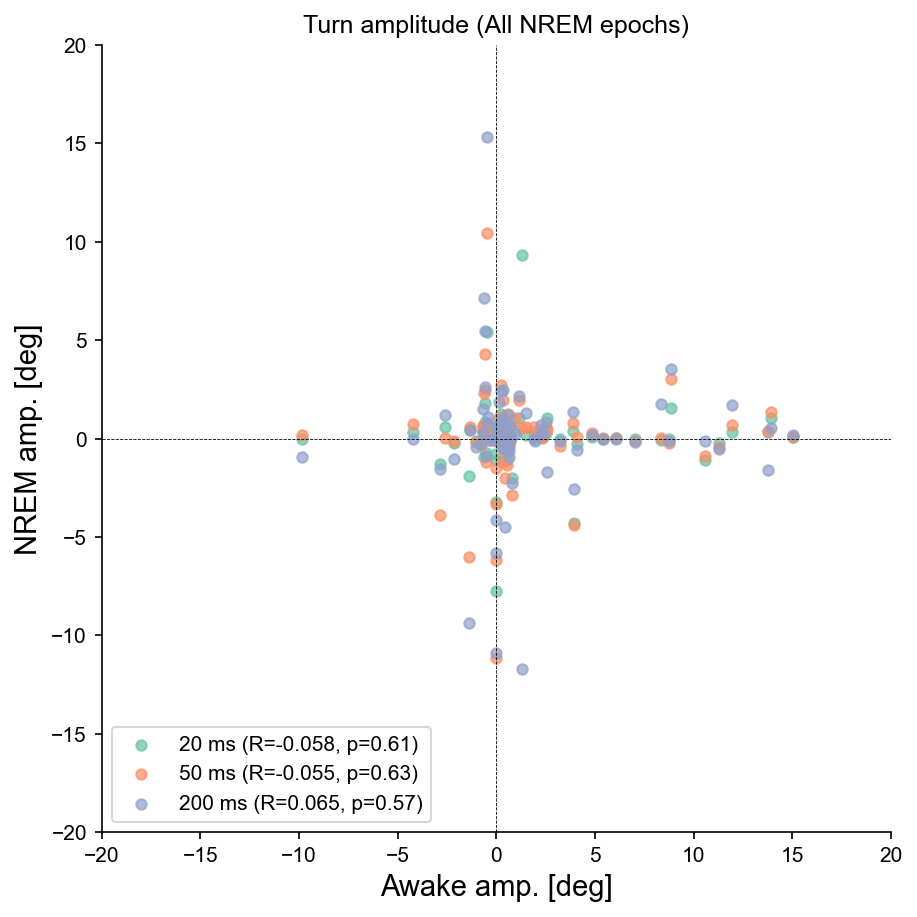

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, thresh in enumerate([0.02, 0.05, 0.2]):
    ax.scatter(awake_amp, turn_amps[:, i], label=f"{(thresh * 1000):.0f} ms (R={results.statistic[i]:.3f}, p={results.pvalue[i]:.2f})", color=cm(i), s=25, alpha=0.7)

ax.set_xlabel("Awake amp. [deg]", fontsize=14)
ax.set_ylabel("NREM amp. [deg]", fontsize=14)

ax.set_title("Turn amplitude (All NREM epochs)")

ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)

ax.axhline(0, color='k', linestyle='--', linewidth=0.4)
ax.axvline(0, color='k', linestyle='--', linewidth=0.4)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend(loc='lower left')
plt.savefig(FIGURES_DIR / "turn_amplitude_all.png")

In [6]:
sta_awake = []
sta_nrem = []

for mouse_id in MOUSE_IDS:
    mouse_dir = DATA_DIR / mouse_id
    
    sta_awake.append(nap.load_file(mouse_dir / "sta_awake.npz").d)
    sta_nrem.append(nap.load_file(mouse_dir / "sta_nrem_cont.npz").d)

sta_awake = np.concatenate(sta_awake, axis=1)
sta_nrem = np.concatenate(sta_nrem, axis=1)
t = nap.load_file(mouse_dir / "sta_awake.npz").t

before_idx = np.where(t == -0.2)[0][0]
after_idx = np.where(t == 0.2)[0][0] + 1
awake_amp = sta_awake[after_idx, :] - sta_awake[before_idx, :]

turn_amps = []
for thresh in [0.02, 0.05, 0.2]:
    before_idx = np.where(t == -thresh)[0][0]
    after_idx = np.where(t == thresh)[0][0] + 1
    turn_amp = sta_nrem[after_idx, :] - sta_nrem[before_idx, :]
    turn_amps.append(turn_amp)
turn_amps = np.column_stack(turn_amps)
results = stats.pearsonr(np.repeat(awake_amp[:, None], 3, axis=1), turn_amps)

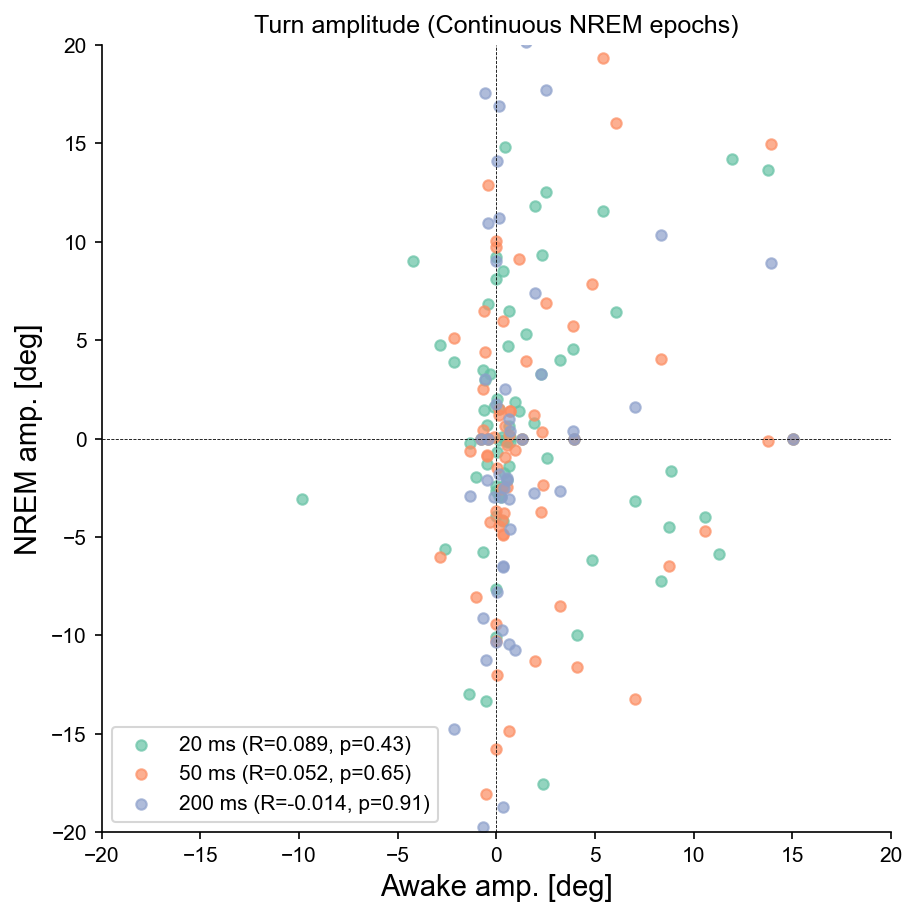

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

for i, thresh in enumerate([0.02, 0.05, 0.2]):
    ax.scatter(awake_amp, turn_amps[:, i], label=f"{(thresh * 1000):.0f} ms (R={results.statistic[i]:.3f}, p={results.pvalue[i]:.2f})", color=cm(i), s=25, alpha=0.7)

ax.set_xlabel("Awake amp. [deg]", fontsize=14)
ax.set_ylabel("NREM amp. [deg]", fontsize=14)

ax.set_title("Turn amplitude (Continuous NREM epochs)")

ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)

ax.axhline(0, color='k', linestyle='--', linewidth=0.4)
ax.axvline(0, color='k', linestyle='--', linewidth=0.4)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend(loc='lower left')
plt.savefig(FIGURES_DIR / "turn_amplitude_cont.png")